In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/raw.csv')

df.shape
display(df.head())
df.info()
df.isnull().sum()


,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD)
0,63,1,True,True,True,Shahran,1.850000e+09,61666.67
1,60,1,True,True,True,Shahran,1.850000e+09,61666.67
2,79,2,True,True,True,Pardis,5.500000e+08,18333.33
3,95,2,True,True,True,Shahrake Qods,9.025000e+08,30083.33
4,123,2,True,True,True,Shahrake Gharb,7.000000e+09,233333.33


<class 'pandas.DataFrame'>
RangeIndex: 3479 entries, 0 to 3478
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Area        3479 non-null   str    
 1   Room        3479 non-null   int64  
 2   Parking     3479 non-null   bool   
 3   Warehouse   3479 non-null   bool   
 4   Elevator    3479 non-null   bool   
 5   Address     3456 non-null   str    
 6   Price       3479 non-null   float64
 7   Price(USD)  3479 non-null   float64
dtypes: bool(3), float64(2), int64(1), str(2)
memory usage: 146.2 KB


Area           0
Room           0
Parking        0
Warehouse      0
Elevator       0
Address       23
Price          0
Price(USD)     0
dtype: int64

Convert 'Area' from str to number.

In [ ]:
# Check the actual data types in the column
print(df['Area'].apply(type).value_counts())

# Clean string values (if commas exist) and convert to numeric
df['Area'] = df['Area'].astype(str).str.replace(',', '').str.strip()
df['Area'] = pd.to_numeric(df['Area'], errors='coerce')

print("Number of rows with conversion errors (NaN):", df['Area'].isnull().sum())
df = df.dropna(subset=['Area'])

Area
<class 'str'>    3479
Name: count, dtype: int64
Số dòng lỗi convert (NaN): 0


In [ ]:
# Remove rows with clearly invalid Area values
# (unrealistically large values, e.g., in the billions, which are not plausible for house area)
print("Number of rows with Area > 10,000:", (df['Area'] > 10000).sum())
df = df[df['Area'] <= 10000]

Số dòng Area > 10,000: 4


In [ ]:
print("Number of rows with Area > 2,000:", (df['Area'] > 2000).sum())
df = df[df['Area'] <= 2000]

df['Area'].describe()

Số dòng Area > 2000: 1


count    3474.000000
mean      107.031664
std        70.991973
min        30.000000
25%        69.000000
50%        90.000000
75%       120.000000
max      1000.000000
Name: Area, dtype: float64

Data has some outlier value in area, it affect the plot that will
be drawn in the next step, so i choose to delete them.

In [ ]:
print(df[['Price', 'Price(USD)']].corr())
df = df.drop(columns=['Price'])

# Change the name for easier operation
df = df.rename(columns={'Price(USD)': 'Price_USD'})
target = 'Price_USD'

            Price  Price(USD)
Price         1.0         1.0
Price(USD)    1.0         1.0


Classification based on data format

In [ ]:
numeric_cols = ['Area', 'Room']
boolean_cols = ['Parking', 'Warehouse', 'Elevator']
categorical_cols = ['Address']

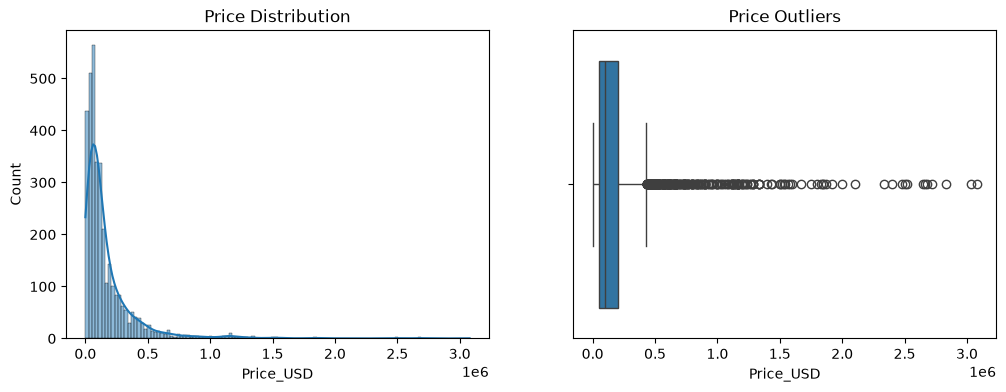

Skewness: 4.78136064205584


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df[target], kde=True, ax=axes[0])
axes[0].set_title('Price Distribution')

sns.boxplot(x=df[target], ax=axes[1])
axes[1].set_title('Price Outliers')

plt.show()

print("Skewness:", df[target].skew())

The distribution of the target variable is heavily right-skewed, indicating the presence of a small number of extremely high price values. These extreme values can negatively affect the training process, particularly for linear regression models. Therefore, we apply a log transformation to reduce the skewness, stabilize the variance, and make the distribution more closely resemble a normal distribution.

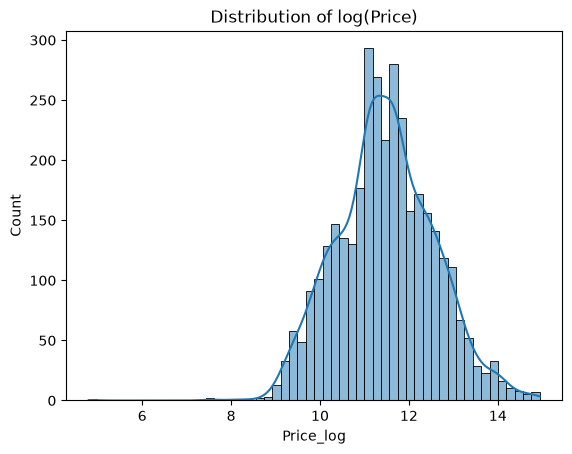

In [ ]:
df['Price_log'] = np.log1p(df[target])

sns.histplot(df['Price_log'], kde=True)
plt.title('Distribution of log(Price)')
plt.show()

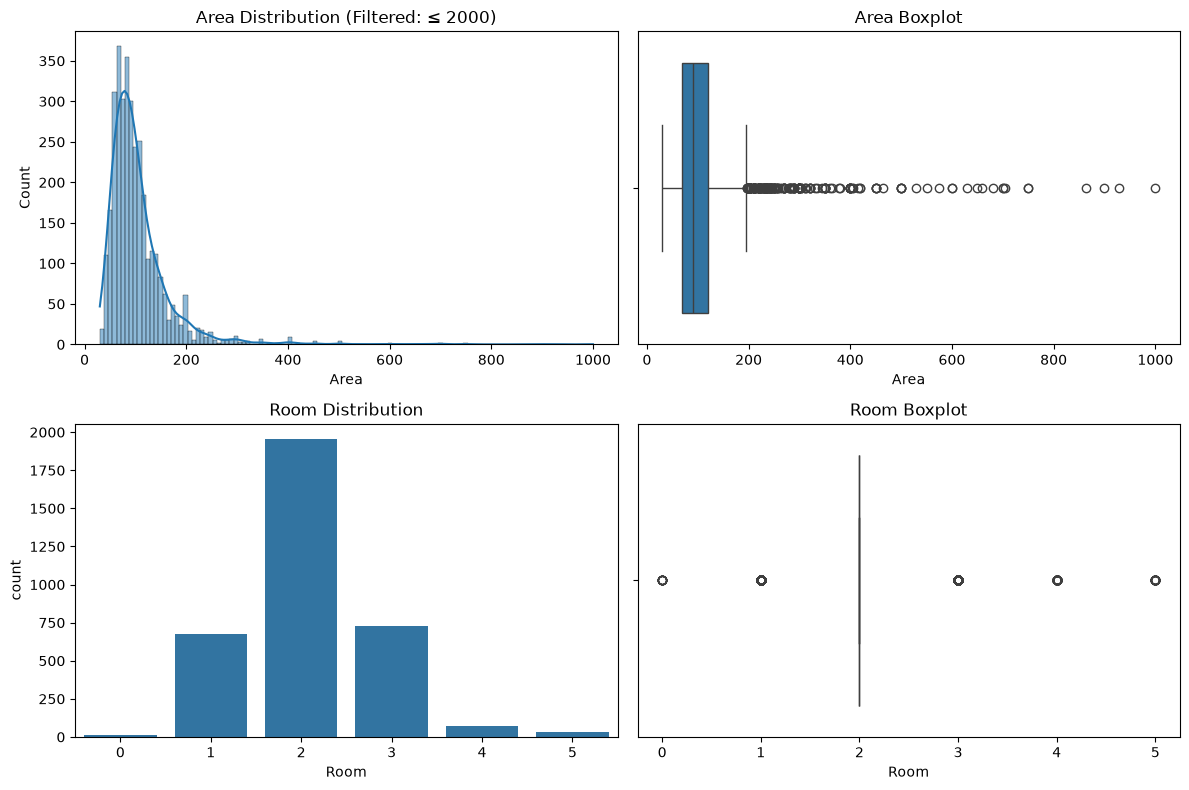

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(df['Area'], kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Area Distribution (Filtered: ≤ 2000)')

sns.boxplot(x=df['Area'], ax=axes[0, 1])
axes[0, 1].set_title('Area Boxplot')

sns.countplot(x='Room', data=df, ax=axes[1, 0])
axes[1, 0].set_title('Room Distribution')

sns.boxplot(x=df['Room'], ax=axes[1, 1])
axes[1, 1].set_title('Room Boxplot')

plt.tight_layout()
plt.show()

The distribution of Area remains heavily right-skewed, even after removing the majority of extreme values. Therefore, a log transformation will also be applied to this feature to reduce skewness and improve its distribution for model training.

The Room feature is highly concentrated around 2 rooms, causing the boxplot to appear almost like a single line. However, the remaining values are not considered outliers, as they represent valid and realistic observations. Therefore, no additional filtering is performed on this feature.

In [ ]:
df['Area_log'] = np.log1p(df['Area'])

fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.histplot(df['Area'], kde=True, ax=axes[0])
axes[0].set_title('Phân phối Area (gốc)')
sns.histplot(df['Area_log'], kde=True, ax=axes[1])
axes[1].set_title('Phân phối log(Area)')
plt.show()

print("Skewness Area gốc:", df['Area'].skew())
print("Skewness Area_log:", df['Area_log'].skew())

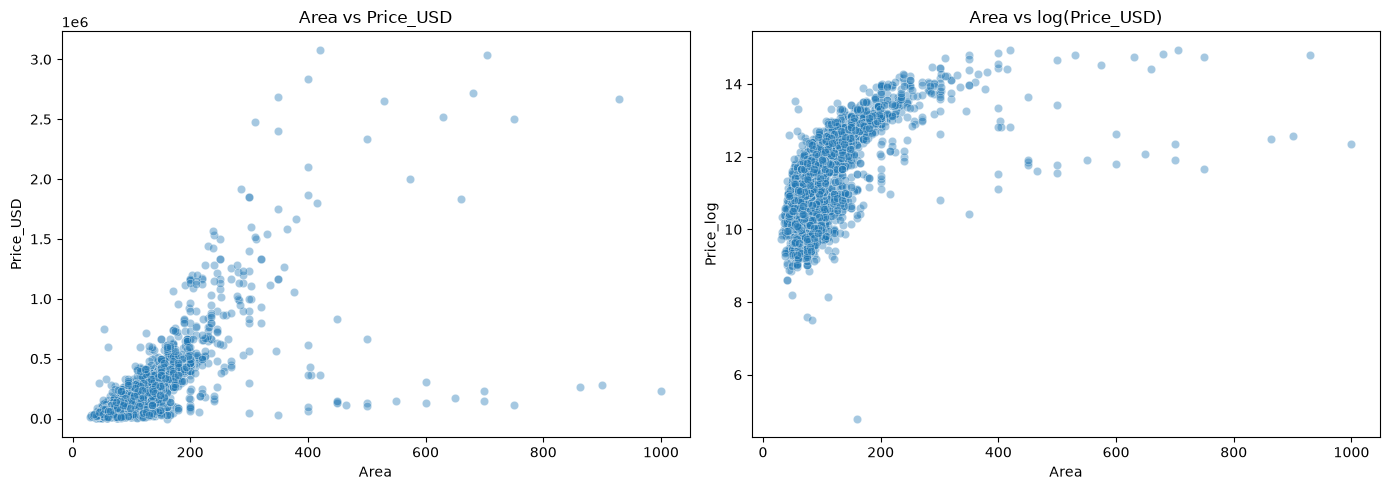

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.scatterplot(x='Area_log', y=target, data=df, alpha=0.4, ax=axes[0])
axes[0].set_title('log(Area) vs Price_USD')

sns.scatterplot(x='Area_log', y='Price_log', data=df, alpha=0.4, ax=axes[1])
axes[1].set_title('log(Area) vs log(Price_USD)')
plt.tight_layout()
plt.show()

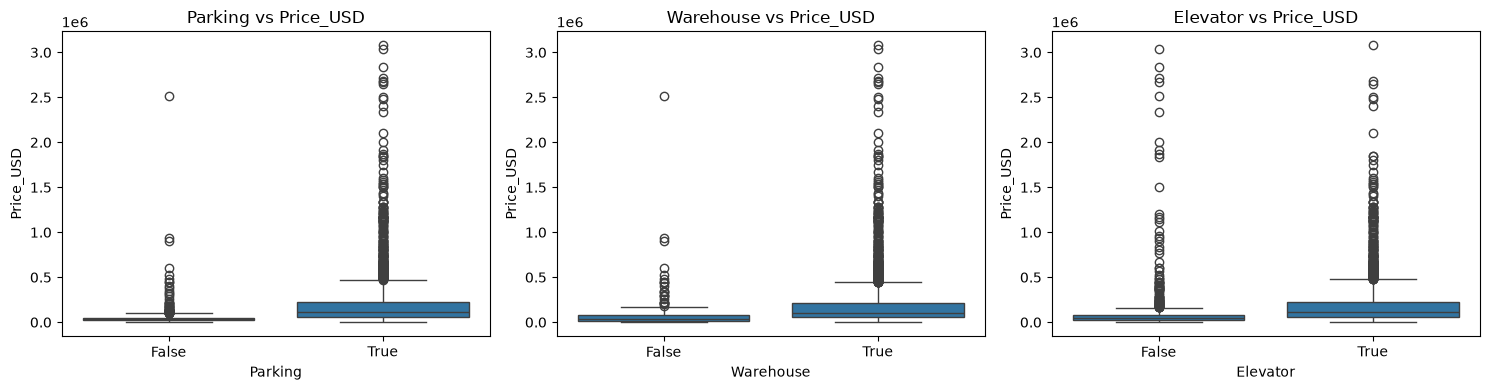

Parking
False     56949.350038
True     200288.779260
Name: Price_USD, dtype: float64

Warehouse
False     81176.700845
True     187568.186617
Name: Price_USD, dtype: float64

Elevator
False    120477.059161
True     194181.884388
Name: Price_USD, dtype: float64



In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, col in zip(axes, boolean_cols):
    sns.boxplot(x=col, y=target, data=df, ax=ax)
    ax.set_title(f'{col} vs Price_USD')
plt.tight_layout()
plt.show()

for col in boolean_cols:
    print(df.groupby(col)[target].mean())
    print()

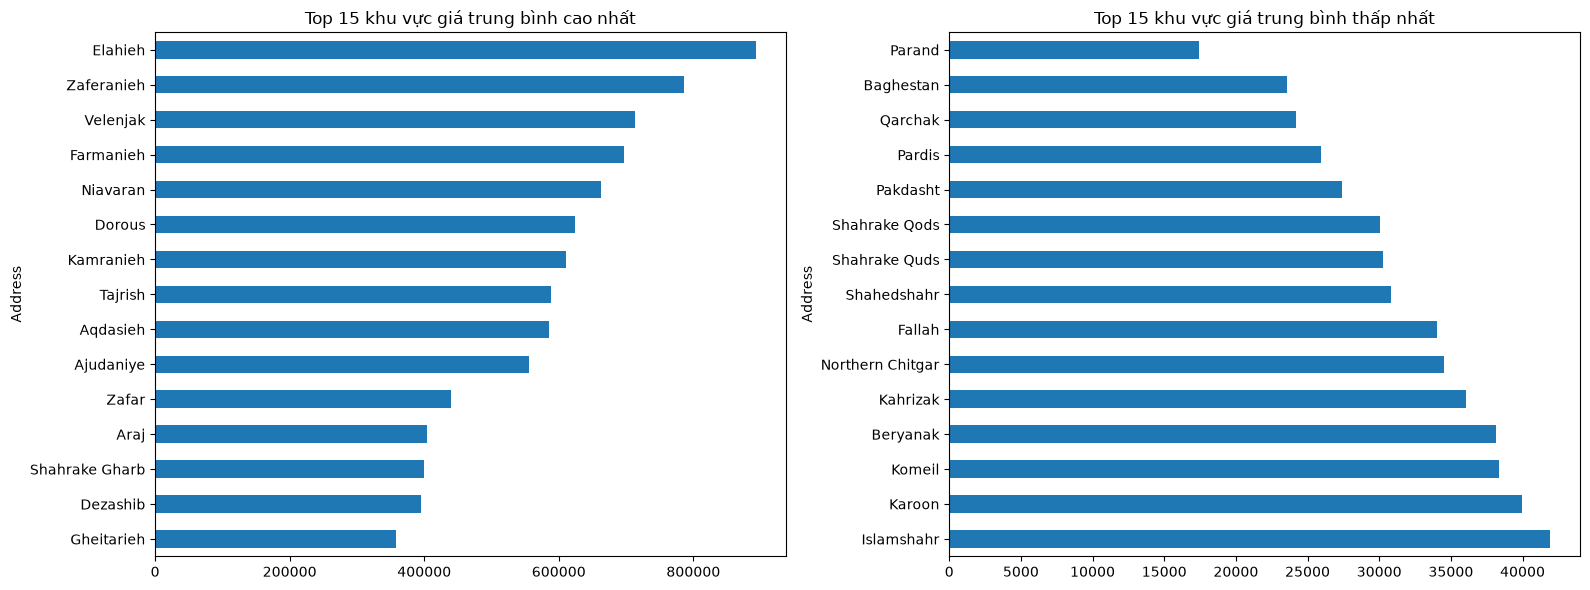

Tổng số khu vực (Address) khác nhau: 192


In [ ]:
top_addr = df.groupby('Address')[target].agg(['mean','count']).sort_values('mean', ascending=False)
top_addr = top_addr[top_addr['count'] >= 5]   # lọc khu vực đủ số mẫu

fig, axes = plt.subplots(1, 2, figsize=(16,6))
top_addr.head(15)['mean'].plot(kind='barh', ax=axes[0])
axes[0].set_title('Top 15 khu vực giá trung bình cao nhất')
axes[0].invert_yaxis()

top_addr.tail(15)['mean'].plot(kind='barh', ax=axes[1])
axes[1].set_title('Top 15 khu vực giá trung bình thấp nhất')
plt.tight_layout()
plt.show()

print("Tổng số khu vực (Address) khác nhau:", df['Address'].nunique())

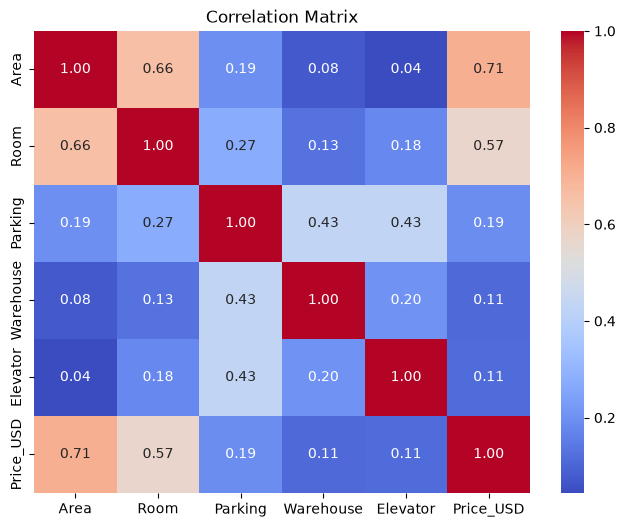

Price_USD    1.000000
Area         0.706721
Room         0.567599
Parking      0.190551
Elevator     0.111688
Warehouse    0.109987
Name: Price_USD, dtype: float64


In [ ]:
corr_cols = ['Area', 'Room', 'Parking', 'Warehouse', 'Elevator', target]
df_corr = df[corr_cols].copy()

for col in boolean_cols:
    df_corr[col] = df_corr[col].astype(int)

plt.figure(figsize=(8,6))
sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

print(df_corr.corr()[target].sort_values(ascending=False))